In [ ]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_depth.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_depth.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band.cat"

ZP_i = 30.954
ZP_z = 30.568
ZP_nb = 29.12549

# ---------- Load catalogs ----------
colnames = [
    "ID", "X", "Y", "RA", "DEC",
    "MAG_APER", "MAGERR_APER",
    "MAG_AUTO", "MAGERR_AUTO",
    "FLAGS"
]

i_df = pd.read_csv(i_file, sep='\s+', comment='#', names=colnames)
z_df = pd.read_csv(z_file, sep='\s+', comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep='\s+', comment='#', names=colnames)

# ---------- Convert to SkyCoord ----------
i_coord = SkyCoord(ra=i_df["RA"].values * u.deg, dec=i_df["DEC"].values * u.deg)
z_coord = SkyCoord(ra=z_df["RA"].values * u.deg, dec=z_df["DEC"].values * u.deg)
nb_coord = SkyCoord(ra=nb_df["RA"].values * u.deg, dec=nb_df["DEC"].values * u.deg)

# ---------- Match i/z to NB ----------
i2nb_idx, i2nb_sep, _ = i_coord.match_to_catalog_sky(nb_coord)
z2nb_idx, z2nb_sep, _ = z_coord.match_to_catalog_sky(nb_coord)

i_match_mask = i2nb_sep.arcsec < 1.0
z_match_mask = z2nb_sep.arcsec < 1.0

# ---------- Matched NB indices ----------
nb_indices_i = i2nb_idx[i_match_mask]
nb_indices_z = z2nb_idx[z_match_mask]

# ---------- Find common NB sources ----------
common_nb_indices = np.intersect1d(nb_indices_i, nb_indices_z)

# ---------- Build index maps for reverse match ----------
nb_to_i = {
    nb_idx: i_idx for i_idx, nb_idx in zip(np.where(i_match_mask)[0], nb_indices_i)
    if nb_idx in common_nb_indices
}
nb_to_z = {
    nb_idx: z_idx for z_idx, nb_idx in zip(np.where(z_match_mask)[0], nb_indices_z)
    if nb_idx in common_nb_indices
}

# ---------- Final matched indices ----------
final_nb_idx = sorted(nb_to_i.keys())
i_matches = i_df.iloc[[nb_to_i[idx] for idx in final_nb_idx]].reset_index(drop=True)
z_matches = z_df.iloc[[nb_to_z[idx] for idx in final_nb_idx]].reset_index(drop=True)
nb_matches = nb_df.iloc[final_nb_idx].reset_index(drop=True)

# ---------- Sanity check ----------
assert len(i_matches) == len(z_matches) == len(nb_matches)

# ---------- Output example ----------
print(f"Matched {len(i_matches)} sources between NB, i, and z bands.")
print(i_matches.head())
print(z_matches.head())
print(nb_matches.head())


Matched 433363 sources between NB, i, and z bands.
    ID           X       Y          RA        DEC  MAG_APER  MAGERR_APER  \
0   94  10342.1709  4.3452  357.402403 -31.817859   -5.1983       0.1936   
1  261  19069.3008  7.2661  356.632371 -31.816887   -5.1979       0.1939   
2  204   8967.7510  3.3171  357.523673 -31.817632   -5.8514       0.1020   
3   77  16437.2148  2.7253  356.864603 -31.817943   -6.0198       0.0837   
4   86  18545.0879  2.9598  356.678620 -31.817386   -6.3878       0.0608   

   MAG_AUTO  MAGERR_AUTO  FLAGS  
0   -5.3929       0.2108     16  
1   -5.3995       0.1969     24  
2   -6.4093       0.1490     24  
3   -5.7590       0.1495     24  
4   -6.4515       0.1045     24  
    ID           X       Y          RA        DEC  MAG_APER  MAGERR_APER  \
0   59  10341.3125  3.3658  357.402435 -31.817921   -4.3304       0.3126   
1  301  19069.7949  6.3215  356.632282 -31.816958   -5.3636       0.1250   
2  131   8965.5703  3.3168  357.523821 -31.817618   -5.6814 

In [50]:
import numpy as np

def mag_err_to_snr(mag_err):
    """Convert magnitude error to SNR."""
    mag_err = np.clip(mag_err, 1e-6, None)  # avoid division by zero
    return (2.5 / np.log(10)) / mag_err

# Mask out bad magnitudes 
def valid_mag_mask(mags, bad_value=99):
    """Return a boolean mask for valid magnitudes (not equal to bad_value)."""
    return (mags < bad_value) & (mags > -100)  # also exclude negative large invalid mags

# Extract magnitudes
mag_i = i_matches["MAG_AUTO"].values +33
mag_z = z_matches["MAG_AUTO"].values +33
mag_nb = nb_matches["MAG_AUTO"].values +30

# Build masks for valid mags in each band
valid_i = valid_mag_mask(mag_i)
valid_z = valid_mag_mask(mag_z)
valid_nb = valid_mag_mask(mag_nb)

# Combine to find sources valid in all bands
valid_all = valid_i & valid_z & valid_nb

# Apply this mask to mags and errors to avoid bad data contaminating colors/SNR
mag_i = mag_i[valid_all]
mag_z = mag_z[valid_all]
mag_nb = mag_nb[valid_all]
magerr_i = i_matches["MAGERR_AUTO"].values[valid_all]

# Calculate colors
color_z_nb = mag_z - mag_nb
color_i_z = mag_i - mag_z

# Calculate Kron i-band SNR for filtered data
i_kron_snr = mag_err_to_snr(magerr_i)

# Apply selection criteria on filtered data
mask = (
    (color_z_nb > 0.78) &
    (color_i_z > 1.0) &
    (i_kron_snr < 2)
)

print(f"Number of candidates passing all criteria: {np.sum(mask)}")

# Select candidates from original matched catalogs using the combined valid_all mask
# First find the indices of valid_all = True, then filter those by mask
valid_indices = np.where(valid_all)[0]
candidate_indices = valid_indices[mask]

i_candidates = i_matches.iloc[candidate_indices]
z_candidates = z_matches.iloc[candidate_indices]
nb_candidates = nb_matches.iloc[candidate_indices]

#print(i_candidates.head())
#print(z_candidates.head())
print(nb_candidates.head())


Number of candidates passing all criteria: 148
        ID           X         Y          RA        DEC  MAG_APER  \
137    454   7196.8955   19.4982  357.679912 -31.815824   -4.7571   
663   1565  17021.7832  104.6346  356.813052 -31.810175   -4.0994   
1029  2141  15150.2988  126.8917  356.978171 -31.808820   -6.2166   
1925  3442   6931.1084  253.3139  357.703257 -31.798195   -5.3476   
2059  3622  19769.2207  288.8782  356.570745 -31.795518   -4.7493   

      MAGERR_APER  MAG_AUTO  MAGERR_AUTO  FLAGS  
137        0.1204   -4.7552       0.2059      2  
663        0.2213   -4.6572       0.2605      2  
1029       0.0314   -6.3476       0.0882      3  
1925       0.0702   -5.5397       0.1558      3  
2059       0.1219   -5.1457       0.1381      0  


In [51]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
from typing import List, Tuple

# ---------- Find Closest DECam Object ----------
def find_closest_objects(decam_df: pd.DataFrame, target_coords: List[Tuple[str, str]]) -> pd.DataFrame:
    """
    Finds the closest object in decam_df to each input RA,Dec coordinate.
    decam_df must have columns 'ALPHAPEAK_J2000' and 'DELTAPEAK_J2000'.
    """
    decam_coords = SkyCoord(ra=decam_df['ALPHAPEAK_J2000'].values * u.deg,
                            dec=decam_df['DELTAPEAK_J2000'].values * u.deg)

    results = []
    for i, (ra_str, dec_str) in enumerate(target_coords):
        target = SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg))
        idx, sep2d, _ = target.match_to_catalog_sky(decam_coords)
        closest_obj = decam_df.iloc[idx]
        results.append({
            'Target': f'LAE {i+1}',
            'Input_RA': target.ra.deg,
            'Input_Dec': target.dec.deg,
            'Matched_RA': closest_obj['ALPHAPEAK_J2000'],
            'Matched_Dec': closest_obj['DELTAPEAK_J2000'],
            'Separation_arcsec': sep2d.arcsecond
        })
    return pd.DataFrame(results)

# ---------- Example Usage ----------
if __name__ == '__main__':
    # nb_candidates is your DataFrame of 148 sources
    # Rename RA and DEC to what the function expects
    decam_df = nb_candidates.rename(columns={'RA':'ALPHAPEAK_J2000','DEC':'DELTAPEAK_J2000'})

    # Input coordinates (RA in HH:MM:SS.SSS, Dec in DD:MM:SS.SS)
    input_targets = [
        ("23:48:33.33", "-30:54:10.23"),  # QSO
        ("23:50:39.46", "-31:47:26.41"),  # LAE-1
        ("23:49:25.39", "-31:46:34.95"),  # LAE-2
        ("23:49:45.53", "-31:39:01.46"),  # LAE-3
        ("23:48:22.23", "-31:37:53.92"),  # LAE-4
        ("23:48:17.08", "-31:30:18.94"),  # LAE-5
        ("23:46:51.65", "-31:19:29.93"),  # LAE-6
        ("23:52:04.95", "-31:16:20.60"),  # LAE-7
        ("23:44:51.34", "-31:14:01.78"),  # LAE-8
        ("23:49:09.11", "-31:11:23.68"),  # LAE-9
        ("23:48:38.18", "-31:10:25.49"),  # LAE-10
        ("23:52:11.44", "-31:10:09.82"),  # LAE-11
        ("23:50:09.67", "-31:00:28.43"),  # LAE-12
        ("23:52:50.08", "-30:59:23.05"),  # LAE-13
        ("23:46:52.33", "-30:57:07.02"),  # LAE-14
        ("23:52:39.27", "-30:51:50.73"),  # LAE-15
        ("23:51:42.32", "-30:50:46.97"),  # LAE-16
        ("23:45:30.76", "-30:50:42.20"),  # LAE-17
        ("23:45:38.56", "-30:41:06.23"),  # LAE-18
        ("23:50:56.96", "-30:40:16.95"),  # LAE-19
        ("23:46:20.25", "-30:40:03.94"),  # LAE-20
        ("23:48:12.27", "-30:32:34.32"),  # LAE-21
        ("23:44:45.07", "-30:31:07.12"),  # LAE-22
        ("23:47:37.50", "-30:28:28.35"),  # LAE-23
        ("23:44:31.64", "-30:27:35.79"),  # LAE-24
        ("23:47:38.55", "-30:25:47.75"),  # LAE-25
        ("23:44:36.91", "-30:25:04.43"),  # LAE-26
        ("23:48:21.02", "-30:24:04.19"),  # LAE-27
        ("23:47:21.19", "-30:22:53.54"),  # LAE-28
        ("23:46:27.28", "-30:21:51.57"),  # LAE-29
        ("23:49:27.05", "-30:21:25.98"),  # LAE-30
        ("23:50:27.20", "-30:21:13.39"),  # LAE-31
        ("23:45:02.91", "-30:12:32.87"),  # LAE-32
        ("23:49:34.65", "-30:12:40.49"),  # LAE-33
        ("23:50:23.24", "-30:10:45.41"),  # LAE-34
        ("23:50:45.07", "-30:05:13.35"),  # LAE-35
        ("23:49:43.48", "-30:03:01.26"),  # LAE-36
        ("23:50:36.54", "-30:01:46.79"),  # LAE-37
        ("23:48:43.58", "-29:53:13.94"),  # LAE-38
    ]

    # Find closest NB candidate for each LAE
    closest_df = find_closest_objects(decam_df, input_targets)

    print("\nClosest DECam Detections:")
    print(closest_df.to_string(index=False))



Closest DECam Detections:
Target   Input_RA  Input_Dec  Matched_RA  Matched_Dec    Separation_arcsec
 LAE 1 357.138875 -30.902842  357.009587   -30.845929 [448.95909274963776]
 LAE 2 357.664417 -31.790669  357.679912   -31.815824 [102.21510857006888]
 LAE 3 357.355792 -31.776375  357.272544   -31.665279  [474.2812202958238]
 LAE 4 357.439708 -31.650406  357.272544   -31.665279  [515.0346408453294]
 LAE 5 357.092625 -31.631644  357.113467   -31.646501  [83.31229308681532]
 LAE 6 357.071167 -31.505261  357.143490   -31.548497 [271.07524040600526]
 LAE 7 356.715208 -31.324981  356.947142   -31.302814   [717.783141238573]
 LAE 8 358.020625 -31.272389  358.027852   -31.380479   [389.759586101323]
 LAE 9 356.213917 -31.233828  356.273920   -31.187630 [248.57821740590018]
LAE 10 357.287958 -31.189911  357.323868   -31.240984  [214.5432397532336]
LAE 11 357.159083 -31.173747  357.223237   -31.315084  [545.7827084850062]
LAE 12 358.047667 -31.169394  358.097781   -31.132062 [204.69717100172278

In [52]:
# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_depth.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_depth.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band.cat"

# ---------- Load catalogs ----------
colnames = [
    "ID", "X", "Y", "RA", "DEC",
    "MAG_APER", "MAGERR_APER",
    "MAG_AUTO", "MAGERR_AUTO",
    "FLAGS"
]

i_df = pd.read_csv(i_file, sep='\s+', comment='#', names=colnames)
z_df = pd.read_csv(z_file, sep='\s+', comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep='\s+', comment='#', names=colnames)


In [33]:
import numpy as np
import pandas as pd

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_depth.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_depth.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band.cat"



In [34]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ----------------- Load Catalogs -----------------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df = pd.read_csv(i_file, sep='\s+', comment='#', names=colnames)
z_df = pd.read_csv(z_file, sep='\s+', comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep='\s+', comment='#', names=colnames)

# Compute SNR
def magerr_to_snr(err):
    snr = (2.5/np.log(10))/err

    snr[np.isinf(snr)] = 0
    return snr
ZP_i = 30.954          #30.954
ZP_z = 30.568          # 30.568
ZP_nb = 29.12549

i_df["SNR"] = magerr_to_snr(i_df["MAGERR_AUTO"])
#z_df["SNR"] = magerr_to_snr(z_df["MAGERR_APER"])
#nb_df["SNR"] = magerr_to_snr(nb_df["MAGERR_APER"])

# ----------------- Cross-match -----------------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg) #finds closest source
z_coords = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

# Match NB to Z and I
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords) #indexing the closest source
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

# 1 arcsec matching radius
z_match = sep_z.arcsec < 1.0 # matching but while doing this should we match i and z band ?
i_match = sep_i.arcsec < 1.0

# Assign mags (use np.inf for non-detections)
nb_mag = nb_df["MAG_APER"].values+ ZP_nb
nb_err = nb_df["MAGERR_APER"].values

z_mag = np.full_like(nb_mag, 99.0)  # placeholder for non-detections magnitudes
z_err = np.full_like(nb_mag, 9.9) # error placeholder
z_mag[z_match] = z_df["MAG_APER"].values[idx_z[z_match]] + ZP_z
z_err[z_match] = z_df["MAGERR_APER"].values[idx_z[z_match]]

i_mag = np.full_like(nb_mag, 99.0)
i_err = np.full_like(nb_mag, 9.9)
i_mag[i_match] = i_df["MAG_APER"].values[idx_i[i_match]]+ ZP_i
i_err[i_match] = i_df["MAGERR_APER"].values[idx_i[i_match]]

# Compute SNR for i-band Kron
i_snr = np.zeros_like(nb_mag)
i_snr[i_match] = (2.5/np.log(10)) / i_err[i_match]

# ----------------- Selection -----------------
color_nb = z_mag - nb_mag
color_err = 2.5*np.hypot(z_err, nb_err)

narrow_sel = (color_nb > 0.78) & (np.abs(color_nb) > color_err)
cont_sel = (i_mag - z_mag > 1.0)
i_band_sel = (i_snr < 2.0)
i_kron_sel = magerr_to_snr(i_err) < 2.0  # i-band SNR < 2.0

# Combine for LAE candidates
lae_idx = np.where(narrow_sel & cont_sel & i_band_sel & i_kron_sel)[0]
lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_AUTO", "MAGERR_AUTO"]]

print(f"Selected {len(lae_candidates)} LAE candidates.")


Selected 5580 LAE candidates.


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_88463/1479030009.py:58: RuntimeWarning: divide by zero encountered in divide
  i_snr[i_match] = (2.5/np.log(10)) / i_err[i_match]
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_88463/1479030009.py:17: RuntimeWarning: divide by zero encountered in divide
  snr = (2.5/np.log(10))/err


In [36]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
from typing import List, Tuple

# ---------- Find Closest DECam Object ----------
def find_closest_objects(decam_df: pd.DataFrame, target_coords: List[Tuple[str, str]]) -> pd.DataFrame:
    """
    Finds the closest object in decam_df to each input RA,Dec coordinate.
    decam_df must have columns 'ALPHAPEAK_J2000' and 'DELTAPEAK_J2000'.
    """
    decam_coords = SkyCoord(ra=decam_df['ALPHAPEAK_J2000'].values * u.deg,
                            dec=decam_df['DELTAPEAK_J2000'].values * u.deg)

    results = []
    for i, (ra_str, dec_str) in enumerate(target_coords):
        target = SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg))
        idx, sep2d, _ = target.match_to_catalog_sky(decam_coords)
        closest_obj = decam_df.iloc[idx]
        results.append({
            'Target': f'LAE {i+1}',
            'Input_RA': target.ra.deg,
            'Input_Dec': target.dec.deg,
            'Matched_RA': closest_obj['ALPHAPEAK_J2000'],
            'Matched_Dec': closest_obj['DELTAPEAK_J2000'],
            'Separation_arcsec': sep2d.arcsecond
        })
    return pd.DataFrame(results)


if __name__ == '__main__':
    # Rename RA and DEC to expected column names for the function
    decam_df = lae_candidates.rename(
        columns={'RA': 'ALPHAPEAK_J2000', 'DEC': 'DELTAPEAK_J2000'}
    )

    # List of input targets (RA in HH:MM:SS, Dec in DD:MM:SS)
    input_targets = [
        ("23:48:33.33", "-30:54:10.23"),  # QSO
        ("23:50:39.46", "-31:47:26.41"),  # LAE-1
        ("23:49:25.39", "-31:46:34.95"),  # LAE-2
        ("23:49:45.53", "-31:39:01.46"),  # LAE-3
        ("23:48:22.23", "-31:37:53.92"),  # LAE-4
        ("23:48:17.08", "-31:30:18.94"),  # LAE-5
        ("23:46:51.65", "-31:19:29.93"),  # LAE-6
        ("23:52:04.95", "-31:16:20.60"),  # LAE-7
        ("23:44:51.34", "-31:14:01.78"),  # LAE-8
        ("23:49:09.11", "-31:11:23.68"),  # LAE-9
        ("23:48:38.18", "-31:10:25.49"),  # LAE-10
        ("23:52:11.44", "-31:10:09.82"),  # LAE-11
        ("23:50:09.67", "-31:00:28.43"),  # LAE-12
        ("23:52:50.08", "-30:59:23.05"),  # LAE-13
        ("23:46:52.33", "-30:57:07.02"),  # LAE-14
        ("23:52:39.27", "-30:51:50.73"),  # LAE-15
        ("23:51:42.32", "-30:50:46.97"),  # LAE-16
        ("23:45:30.76", "-30:50:42.20"),  # LAE-17
        ("23:45:38.56", "-30:41:06.23"),  # LAE-18
        ("23:50:56.96", "-30:40:16.95"),  # LAE-19
        ("23:46:20.25", "-30:40:03.94"),  # LAE-20
        ("23:48:12.27", "-30:32:34.32"),  # LAE-21
        ("23:44:45.07", "-30:31:07.12"),  # LAE-22
        ("23:47:37.50", "-30:28:28.35"),  # LAE-23
        ("23:44:31.64", "-30:27:35.79"),  # LAE-24
        ("23:47:38.55", "-30:25:47.75"),  # LAE-25
        ("23:44:36.91", "-30:25:04.43"),  # LAE-26
        ("23:48:21.02", "-30:24:04.19"),  # LAE-27
        ("23:47:21.19", "-30:22:53.54"),  # LAE-28
        ("23:46:27.28", "-30:21:51.57"),  # LAE-29
        ("23:49:27.05", "-30:21:25.98"),  # LAE-30
        ("23:50:27.20", "-30:21:13.39"),  # LAE-31
        ("23:45:02.91", "-30:12:32.87"),  # LAE-32
        ("23:49:34.65", "-30:12:40.49"),  # LAE-33
        ("23:50:23.24", "-30:10:45.41"),  # LAE-34
        ("23:50:45.07", "-30:05:13.35"),  # LAE-35
        ("23:49:43.48", "-30:03:01.26"),  # LAE-36
        ("23:50:36.54", "-30:01:46.79"),  # LAE-37
        ("23:48:43.58", "-29:53:13.94"),  # LAE-38
    ]

    # Find closest candidates
    closest_df = find_closest_objects(decam_df, input_targets)

    # Filter by separation < 1 arcsecond
    matched_within_1arcsec = closest_df[closest_df["Separation_arcsec"] < 1.0]

    print("\nSources with separation < 1 arcsec:")
    print(matched_within_1arcsec.to_string(index=False))
    print(f"\nTotal matches within 1 arcsec: {len(matched_within_1arcsec)}")




Sources with separation < 1 arcsec:
Target   Input_RA  Input_Dec  Matched_RA  Matched_Dec     Separation_arcsec
 LAE 1 357.138875 -30.902842  357.138886   -30.902785  [0.2063047836144257]
 LAE 2 357.664417 -31.790669  357.664518   -31.790719  [0.3575463956966819]
 LAE 8 358.020625 -31.272389  358.020584   -31.272389  [0.1249249205354806]
LAE 17 357.926333 -30.846381  357.926216   -30.846409  [0.3766343233700139]
LAE 25 356.131833 -30.459942  356.131838   -30.459963 [0.07940472595039172]
LAE 26 356.910625 -30.429931  356.910591   -30.429922  [0.1114324840544267]
LAE 30 356.613667 -30.364325  356.613619   -30.364361 [0.19700124697177612]
LAE 31 357.362708 -30.357217  357.362664   -30.357175 [0.20279399004330198]
LAE 36 357.687792 -30.087042  357.687800   -30.086953 [0.32159087563044536]
LAE 39 357.181583 -29.887206  357.181578   -29.887226  [0.0758983707943968]

Total matches within 1 arcsec: 10


In [ ]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_depth.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_depth.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band.cat"

# ---------- Load Catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Define magnitude zero-points ----------
ZP_i  = 30.954
ZP_z  = 30.568
ZP_nb = 29.12549

# Convert MAG_APER to calibrated mags
i_df["MAG_APER_CAL"]  = i_df["MAG_APER"]  + ZP_i
z_df["MAG_APER_CAL"]  = z_df["MAG_APER"]  + ZP_z
nb_df["MAG_APER_CAL"] = nb_df["MAG_APER"] + ZP_nb

ZPERR_i  = 0.02
ZPERR_z  = 0.03
ZPERR_nb = 0.04

i_df["MAGERR_APER_CAL"]  = np.sqrt(i_df["MAGERR_APER"]**2  + ZPERR_i**2)
z_df["MAGERR_APER_CAL"]  = np.sqrt(z_df["MAGERR_APER"]**2  + ZPERR_z**2)
nb_df["MAGERR_APER_CAL"] = np.sqrt(nb_df["MAGERR_APER"]**2 + ZPERR_nb**2)


# ---------- Compute SNR function ----------
def magerr_to_snr(err):
    snr = (2.5 / np.log(10)) / err
    snr[np.isinf(snr)] = 0
    return snr

# Compute SNR for i-band Kron
i_df["SNR_AUTO"] = magerr_to_snr(i_df["MAGERR_AUTO"])

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

# Match NB→Z and NB→I
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec
z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Create aligned magnitude arrays ----------
nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER"].values

z_mag = np.full(nb_mag.shape, 99.0, dtype=float)
z_err = np.full(nb_mag.shape, 9.9, dtype=float)
z_mag[z_match] = z_df["MAG_APER_CAL"].values[idx_z[z_match]]
z_err[z_match] = z_df["MAGERR_APER"].values[idx_z[z_match]]

i_mag = np.full(nb_mag.shape, 99.0, dtype=float)
i_err = np.full(nb_mag.shape, 9.9, dtype=float)
i_mag[i_match] = i_df["MAG_APER_CAL"].values[idx_i[i_match]]
i_err[i_match] = i_df["MAGERR_APER"].values[idx_i[i_match]]

# Compute SNR for i-band aperture
i_snr = np.zeros_like(nb_mag)
i_snr[i_match] = magerr_to_snr(i_err[i_match])

# ---------- Compute NB excess (color) ----------
color_nb  = z_mag - nb_mag
color_err = (2.5 / np.log(10)) * np.hypot(z_err, nb_err)  # Correct propagation

# ---------- Apply LAE Selection ----------
narrow_sel = (color_nb > 0.78) & (color_nb > color_err)    # NB excess
cont_sel   = (i_mag - z_mag > 1.0)                        # Continuum break
i_band_sel = (i_snr < 3.0)                                # Faint in i-band
i_kron_sel = magerr_to_snr(i_err) < 3.0                   # Kron SNR < 3

final_sel = narrow_sel & cont_sel & i_band_sel & i_kron_sel
lae_idx   = np.where(final_sel)[0]

lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_AUTO", "MAGERR_AUTO"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")

# ---------- Diagnostics: which cut is limiting ----------
print("Candidates passing each cut:")
print("NB excess cut      :", narrow_sel.sum())
print("Continuum break    :", cont_sel.sum())
print("i-band faint (APER):", i_band_sel.sum())
print("i-band faint (AUTO):", i_kron_sel.sum())
print("Final LAEs         :", final_sel.sum())

# Save LAE candidates
lae_candidates.to_csv("LAE_candidates.csv", index=False)
print("Saved LAE candidates to LAE_candidates.csv")


Selected 6408 LAE candidates.
Candidates passing each cut:
NB excess cut      : 89898
Continuum break    : 26768
i-band faint (APER): 116743
i-band faint (AUTO): 116743
Final LAEs         : 6408
Saved LAE candidates to LAE_candidates.csv


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_88463/1418231573.py:32: RuntimeWarning: divide by zero encountered in divide
  snr = (2.5 / np.log(10)) / err


In [1]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_final_nbmasked.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_final_nbmasked.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_final_nbmasked.cat"

# ---------- Load Catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Define magnitude zero-points ----------
ZP_i  = 30.954   # corrected
ZP_z  = 30.568
ZP_nb = 29.12549

# Convert MAG_APER to calibrated mags
i_df["MAG_APER_CAL"]  = i_df["MAG_AUTO"]  + ZP_i
z_df["MAG_APER_CAL"]  = z_df["MAG_AUTO"]  + ZP_z
nb_df["MAG_APER_CAL"] = nb_df["MAG_AUTO"] + ZP_nb

ZPERR_i  = 0.02
ZPERR_z  = 0.03
ZPERR_nb = 0.04

i_df["MAGERR_APER_CAL"]  = np.sqrt(i_df["MAGERR_APER"]**2  + ZPERR_i**2)
z_df["MAGERR_APER_CAL"]  = np.sqrt(z_df["MAGERR_APER"]**2  + ZPERR_z**2)
nb_df["MAGERR_APER_CAL"] = np.sqrt(nb_df["MAGERR_APER"]**2 + ZPERR_nb**2)


# ---------- Compute SNR function ----------
def magerr_to_snr(err):
    snr = (2.5 / np.log(10)) / err
    snr[np.isinf(snr)] = 0
    return snr

# Compute SNR for AUTO mags
i_df["SNR_AUTO"] = magerr_to_snr(i_df["MAGERR_AUTO"])

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

# Use 1.5 arcsec to recover faint offsets
match_radius = 1.5  # arcsec
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Create aligned magnitude arrays ----------
nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER"].values

z_mag = np.full(nb_mag.shape, 99.0, dtype=float)
z_err = np.full(nb_mag.shape, 9.9, dtype=float)
z_mag[z_match] = z_df["MAG_APER_CAL"].values[idx_z[z_match]]
z_err[z_match] = z_df["MAGERR_APER"].values[idx_z[z_match]]

i_mag = np.full(nb_mag.shape, 99.0, dtype=float)
i_err = np.full(nb_mag.shape, 9.9, dtype=float)
i_mag[i_match] = i_df["MAG_APER_CAL"].values[idx_i[i_match]]
i_err[i_match] = i_df["MAGERR_APER"].values[idx_i[i_match]]

# Compute SNR for i-band aperture
i_snr_aper = np.zeros_like(nb_mag)
i_snr_aper[i_match] = magerr_to_snr(i_err[i_match])
i_snr_auto = np.zeros_like(nb_mag)
i_snr_auto[i_match] = magerr_to_snr(i_df["MAGERR_AUTO"].values[idx_i[i_match]])

# ---------- Compute NB excess (color) ----------
color_nb  = z_mag - nb_mag
color_err = (2.5 / np.log(10)) * np.hypot(z_err, nb_err)  # mag error propagation

# ---------- Apply LAE Selection ----------
narrow_sel = (color_nb > 0.78)       # relaxed cut for faint LAEs
cont_sel   = (i_mag - z_mag > 1.0)   # Lyman break
faint_sel  = (i_snr_aper < 2.0) | (i_snr_auto < 2.0)  # faint in i-band
# ---------- Compute color error for significance cut ----------
sigma_color = np.sqrt(z_err**2 + nb_err**2)

# ---------- Apply significance cut: |z - NB| > 2.5 * sigma_color ----------
sig_sel = np.abs(z_mag - nb_mag) > 2.5 * sigma_color

# ---------- Update final LAE selection ----------
final_sel = narrow_sel & cont_sel & faint_sel & sig_sel
lae_idx   = np.where(final_sel)[0]

lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_AUTO", "MAGERR_AUTO"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")

# ---------- Diagnostics: which cut is limiting ----------
print("Candidates passing each cut:")
print("NB excess cut     :", narrow_sel.sum())
print("Continuum break   :", cont_sel.sum())
print("Faint in i-band   :", faint_sel.sum())
print("Final LAEs        :", final_sel.sum())

# ---------- Save LAE candidates ----------
lae_candidates.to_csv("LAE_candidates.csv", index=False)
print("Saved LAE candidates to LAE_candidates.csv")

# ---------- Optional: debug which cuts each source failed ----------
debug_df = pd.DataFrame({
    "RA": nb_df["RA"],
    "DEC": nb_df["DEC"],
    "NB_mag": nb_mag,
    "Z_mag": z_mag,
    "I_mag": i_mag,
    "Color_Z-NB": color_nb,
    "Pass_NB": narrow_sel,
    "Pass_Break": cont_sel,
    "Pass_Faint": faint_sel,
    "Final_LAE": final_sel
})
debug_df.to_csv("LAE_debug_diagnostics.csv", index=False)
print("Saved diagnostics to LAE_debug_diagnostics.csv")


Selected 73 LAE candidates.
Candidates passing each cut:
NB excess cut     : 337
Continuum break   : 266
Faint in i-band   : 389
Final LAEs        : 73
Saved LAE candidates to LAE_candidates.csv
Saved diagnostics to LAE_debug_diagnostics.csv


In [2]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_depth.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_depth.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band.cat"

# ---------- Load Catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Define magnitude zero-points & errors ----------
ZP_i,  ZPERR_i  = 30., 0.02
ZP_z,  ZPERR_z  = 30.554, 0.03
ZP_nb, ZPERR_nb = 29.12549, 0.04

# ---------- Convert to calibrated magnitudes ----------
i_df["MAG_APER_CAL"]  = i_df["MAG_APER"]  + ZP_i
z_df["MAG_APER_CAL"]  = z_df["MAG_APER"]  + ZP_z
nb_df["MAG_APER_CAL"] = nb_df["MAG_APER"] + ZP_nb

# ---------- Propagate zero-point errors ----------
i_df["MAGERR_APER_CAL"]  = np.sqrt(i_df["MAGERR_APER"]**2  + ZPERR_i**2)
z_df["MAGERR_APER_CAL"]  = np.sqrt(z_df["MAGERR_APER"]**2  + ZPERR_z**2)
nb_df["MAGERR_APER_CAL"] = np.sqrt(nb_df["MAGERR_APER"]**2 + ZPERR_nb**2)

# ---------- SNR function ----------
def magerr_to_snr(err):
    snr = (2.5 / np.log(10)) / err
    snr[~np.isfinite(snr)] = 0
    return snr

# Compute SNR for i-band AUTO mags
i_df["SNR_AUTO"] = magerr_to_snr(i_df["MAGERR_AUTO"])

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

match_radius = 1.5  # arcsec
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Create aligned magnitude and error arrays ----------
nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER_CAL"].values

z_mag = np.full(nb_mag.shape, 99.0)
z_err = np.full(nb_mag.shape, 9.9)
z_mag[z_match] = z_df["MAG_APER_CAL"].values[idx_z[z_match]]
z_err[z_match] = z_df["MAGERR_APER_CAL"].values[idx_z[z_match]]

i_mag = np.full(nb_mag.shape, 99.0)
i_err = np.full(nb_mag.shape, 9.9)
i_mag[i_match] = i_df["MAG_APER_CAL"].values[idx_i[i_match]]
i_err[i_match] = i_df["MAGERR_APER_CAL"].values[idx_i[i_match]]

# ---------- Compute SNR for i-band ----------
i_snr_aper = np.zeros_like(nb_mag)
i_snr_aper[i_match] = magerr_to_snr(i_err[i_match])
i_snr_auto = np.zeros_like(nb_mag)
i_snr_auto[i_match] = magerr_to_snr(i_df["MAGERR_AUTO"].values[idx_i[i_match]])

# ---------- Colors & errors ----------
color_nb  = z_mag - nb_mag
color_err = np.sqrt(z_err**2 + nb_err**2)  # error in (z - NB)

# ---------- Apply cuts ----------
narrow_sel = (color_nb > 0.78)                  # NB excess
cont_sel   = (i_mag - z_mag > 1.0)              # Lyman break
faint_sel  = (i_snr_aper < 2.0) | (i_snr_auto < 2.0)  # faint in i-band
sig_sel    = np.abs(color_nb) > 2.5 * color_err # 2.5σ significance cut

# Final selection
final_sel = narrow_sel & cont_sel & faint_sel & sig_sel
lae_idx   = np.where(final_sel)[0]

# ---------- Save LAE candidates ----------
lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_AUTO", "MAGERR_AUTO"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")

print("Candidates passing each cut:")
print("NB excess cut     :", narrow_sel.sum())
print("Continuum break   :", cont_sel.sum())
print("Faint in i-band   :", faint_sel.sum())
print("Significance cut  :", sig_sel.sum())
print("Final LAEs        :", final_sel.sum())

lae_candidates.to_csv("LAE_candidates.csv", index=False)
print("Saved LAE candidates to LAE_candidates.csv")

# ---------- Save debug diagnostics ----------
debug_df = pd.DataFrame({
    "RA": nb_df["RA"],
    "DEC": nb_df["DEC"],
    "NB_mag": nb_mag,
    "NB_err": nb_err,
    "Z_mag": z_mag,
    "Z_err": z_err,
    "I_mag": i_mag,
    "I_err": i_err,
    "Color_Z-NB": color_nb,
    "Color_err": color_err,
    "Pass_NB": narrow_sel,
    "Pass_Break": cont_sel,
    "Pass_Faint": faint_sel,
    "Pass_Significance": sig_sel,
    "Final_LAE": final_sel
})
debug_df.to_csv("LAE_debug_diagnostics.csv", index=False)
print("Saved diagnostics to LAE_debug_diagnostics.csv")


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_2714/3372028513.py:37: RuntimeWarning: divide by zero encountered in divide
  snr = (2.5 / np.log(10)) / err


Selected 69710 LAE candidates.
Candidates passing each cut:
NB excess cut     : 365844
Continuum break   : 272191
Faint in i-band   : 605475
Significance cut  : 348208
Final LAEs        : 69710
Saved LAE candidates to LAE_candidates.csv
Saved diagnostics to LAE_debug_diagnostics.csv


In [ ]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_final_nbmasked.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_final_nbmasked.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_final_nbmasked.cat"

# ---------- Load Catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Define magnitude zero-points & errors ----------
ZP_i,  ZPERR_i  = 30.330, 0.002
ZP_z,  ZPERR_z  = 30.230, 0.003
ZP_nb, ZPERR_nb = 29.01078, 0.09539

# ---------- Convert to calibrated magnitudes ----------
i_df["MAG_APER_CAL"]  = i_df["MAG_APER"]  + ZP_i
z_df["MAG_APER_CAL"]  = z_df["MAG_APER"]  + ZP_z
nb_df["MAG_APER_CAL"] = nb_df["MAG_APER"] + ZP_nb

# ---------- Propagate zero-point errors ----------
i_df["MAGERR_APER_CAL"]  = np.sqrt(i_df["MAGERR_APER"]**2  + ZPERR_i**2)
z_df["MAGERR_APER_CAL"]  = np.sqrt(z_df["MAGERR_APER"]**2  + ZPERR_z**2)
nb_df["MAGERR_APER_CAL"] = np.sqrt(nb_df["MAGERR_APER"]**2 + ZPERR_nb**2)

# ---------- SNR function ----------
def magerr_to_snr(err):
    snr = (2.5 /( np.log(10) * err))
    snr[~np.isfinite(snr)] = 0
    return snr

# Compute SNR for i-band AUTO mags
i_df["SNR_AUTO"] = magerr_to_snr(i_df["MAG_APER_CAL"])

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

match_radius = 1  # arcsec
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Create aligned magnitude and error arrays ----------
nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER_CAL"].values

z_mag = np.full(nb_mag.shape, 99.0)
z_err = np.full(nb_mag.shape, 9.9)
z_mag[z_match] = z_df["MAG_APER_CAL"].values[idx_z[z_match]]
z_err[z_match] = z_df["MAGERR_APER_CAL"].values[idx_z[z_match]]

i_mag = np.full(nb_mag.shape, 99.0)
i_err = np.full(nb_mag.shape, 9.9)
i_mag[i_match] = i_df["MAG_APER_CAL"].values[idx_i[i_match]]
i_err[i_match] = i_df["MAGERR_APER_CAL"].values[idx_i[i_match]]

# ---------- Compute SNR for i-band ----------
i_snr_aper = np.zeros_like(nb_mag)
i_snr_aper[i_match] = magerr_to_snr(i_err[i_match])
i_snr_auto = np.zeros_like(nb_mag)
i_snr_auto[i_match] = magerr_to_snr(i_df["MAGERR_APER_CAL"].values[idx_i[i_match]])

# ---------- Colors & errors ----------
color_nb  = z_mag - nb_mag
color_err = np.sqrt(z_err**2 + nb_err**2)  # error in (z - NB)

# ---------- Apply cuts ----------
narrow_sel = (color_nb > 0.78)                  # NB excess
cont_sel   = (i_mag - z_mag > 1.0)              # Lyman break
faint_sel  = (i_snr_aper < 2.0) | (i_snr_auto < 2.0)  # faint in i-band
sig_sel    = np.abs(color_nb) > 2.5 * color_err # 2.5σ significance cut

# Final selection
final_sel = narrow_sel & cont_sel & faint_sel & sig_sel
lae_idx   = np.where(final_sel)[0]

# ---------- Save LAE candidates ----------
lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_APER", "MAGERR_APER"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")

print("Candidates passing each cut:")
print("NB excess cut     :", narrow_sel.sum())
print("Continuum break   :", cont_sel.sum())
print("Faint in i-band   :", faint_sel.sum())
print("Significance cut  :", sig_sel.sum())
print("Final LAEs        :", final_sel.sum())

lae_candidates.to_csv("/Users/aishwarya/Documents/Lyman_alpha/LAE_candidates.cat", index=False)
print("Saved LAE candidates to LAE_candidates.cat")

# ---------- Save debug diagnostics ----------
debug_df = pd.DataFrame({
    "RA": nb_df["RA"],
    "DEC": nb_df["DEC"],
    "NB_mag": nb_mag,
    "NB_err": nb_err,
    "Z_mag": z_mag,
    "Z_err": z_err,
    "I_mag": i_mag,
    "I_err": i_err,
    "Color_Z-NB": color_nb,
    "Color_err": color_err,
    "Pass_NB": narrow_sel,
    "Pass_Break": cont_sel,
    "Pass_Faint": faint_sel,
    "Pass_Significance": sig_sel,
    "Final_LAE": final_sel
})
debug_df.to_csv("LAE_debug_diagnostics.cat", index=False)
print("Saved diagnostics to LAE_debug_diagnostics.cat")


Selected 5458 LAE candidates.
Candidates passing each cut:
NB excess cut     : 123459
Continuum break   : 56061
Faint in i-band   : 129657
Significance cut  : 245937
Final LAEs        : 5458
Saved LAE candidates to LAE_candidates.cat
Saved diagnostics to LAE_debug_diagnostics.cat


In [17]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# ----------------- Convert input targets to SkyCoord -----------------
input_targets = [
    ("23:48:33.33", "-30:54:10.23"),  # QSO
    ("23:50:39.46", "-31:47:26.41"),  # LAE-1
    ("23:49:25.39", "-31:46:34.95"),  # LAE-2
    ("23:49:45.53", "-31:39:01.46"),  # LAE-3
    ("23:48:22.23", "-31:37:53.92"),  # LAE-4
    ("23:48:17.08", "-31:30:18.94"),  # LAE-5
    ("23:46:51.65", "-31:19:29.93"),  # LAE-6
    ("23:52:04.95", "-31:16:20.60"),  # LAE-7
    ("23:44:51.34", "-31:14:01.78"),  # LAE-8
    ("23:49:09.11", "-31:11:23.68"),  # LAE-9
    ("23:48:38.18", "-31:10:25.49"),  # LAE-10
    ("23:52:11.44", "-31:10:09.82"),  # LAE-11
    ("23:50:09.67", "-31:00:28.43"),  # LAE-12
    ("23:52:50.08", "-30:59:23.05"),  # LAE-13
    ("23:46:52.33", "-30:57:07.02"),  # LAE-14
    ("23:52:39.27", "-30:51:50.73"),  # LAE-15
    ("23:51:42.32", "-30:50:46.97"),  # LAE-16
    ("23:45:30.76", "-30:50:42.20"),  # LAE-17
    ("23:45:38.56", "-30:41:06.23"),  # LAE-18
    ("23:50:56.96", "-30:40:16.95"),  # LAE-19
    ("23:46:20.25", "-30:40:03.94"),  # LAE-20
    ("23:48:12.27", "-30:32:34.32"),  # LAE-21
    ("23:44:45.07", "-30:31:07.12"),  # LAE-22
    ("23:47:37.50", "-30:28:28.35"),  # LAE-23
    ("23:44:31.64", "-30:27:35.79"),  # LAE-24
    ("23:47:38.55", "-30:25:47.75"),  # LAE-25
    ("23:44:36.91", "-30:25:04.43"),  # LAE-26
    ("23:48:21.02", "-30:24:04.19"),  # LAE-27
    ("23:47:21.19", "-30:22:53.54"),  # LAE-28
    ("23:46:27.28", "-30:21:51.57"),  # LAE-29
    ("23:49:27.05", "-30:21:25.98"),  # LAE-30
    ("23:50:27.20", "-30:21:13.39"),  # LAE-31
    ("23:45:02.91", "-30:12:32.87"),  # LAE-32
    ("23:49:34.65", "-30:12:40.49"),  # LAE-33
    ("23:50:23.24", "-30:10:45.41"),  # LAE-34
    ("23:50:45.07", "-30:05:13.35"),  # LAE-35
    ("23:49:43.48", "-30:03:01.26"),  # LAE-36
    ("23:50:36.54", "-30:01:46.79"),  # LAE-37
    ("23:48:43.58", "-29:53:13.94"),  # LAE-38
]

input_coords = SkyCoord([ra for ra, dec in input_targets],
                        [dec for ra, dec in input_targets],
                        unit=(u.hourangle, u.deg))

lae_coords = SkyCoord(lae_candidates["RA"].values*u.deg,
                      lae_candidates["DEC"].values*u.deg)

idx, sep2d, _ = input_coords.match_to_catalog_sky(lae_coords)
found_mask = sep2d.arcsec < 1.0  # 1 arcsec tolerance

print("\n--- Check input targets in final LAE candidates ---")
for target, found, sep in zip(input_targets, found_mask, sep2d.arcsec):
    status = "FOUND" if found else f"NOT FOUND (nearest {sep:.2f}\" away)"
    print(f"{target}: {status}")

n_found = found_mask.sum()
print(f"\nNumber of found sources within 1 arcsec: {n_found}")




--- Check input targets in final LAE candidates ---
('23:48:33.33', '-30:54:10.23'): FOUND
('23:50:39.46', '-31:47:26.41'): FOUND
('23:49:25.39', '-31:46:34.95'): FOUND
('23:49:45.53', '-31:39:01.46'): NOT FOUND (nearest 88.70" away)
('23:48:22.23', '-31:37:53.92'): FOUND
('23:48:17.08', '-31:30:18.94'): NOT FOUND (nearest 120.26" away)
('23:46:51.65', '-31:19:29.93'): NOT FOUND (nearest 24.09" away)
('23:52:04.95', '-31:16:20.60'): NOT FOUND (nearest 61.50" away)
('23:44:51.34', '-31:14:01.78'): NOT FOUND (nearest 66.15" away)
('23:49:09.11', '-31:11:23.68'): NOT FOUND (nearest 172.87" away)
('23:48:38.18', '-31:10:25.49'): FOUND
('23:52:11.44', '-31:10:09.82'): NOT FOUND (nearest 165.11" away)
('23:50:09.67', '-31:00:28.43'): NOT FOUND (nearest 26.86" away)
('23:52:50.08', '-30:59:23.05'): NOT FOUND (nearest 37.96" away)
('23:46:52.33', '-30:57:07.02'): FOUND
('23:52:39.27', '-30:51:50.73'): NOT FOUND (nearest 111.43" away)
('23:51:42.32', '-30:50:46.97'): NOT FOUND (nearest 97.03" 

In [1]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import numpy as np

# ---------- Target Coordinates ----------
target_coords = [
    ("23:48:33.33", "-30:54:10.23"),  # QSO
    ("23:50:39.46", "-31:47:26.41"),  # LAE-1
    ("23:49:25.39", "-31:46:34.95"),  # LAE-2
    ("23:49:45.53", "-31:39:01.46"),  # LAE-3
    ("23:48:22.23", "-31:37:53.92"),  # LAE-4
    ("23:48:17.08", "-31:30:18.94"),  # LAE-5
    ("23:46:51.65", "-31:19:29.93"),
    ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"),
    ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"),
    ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"),
    ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"),
    ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"),
    ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"),
    ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"),
    ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"),
    ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"),
    ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"),
    ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"),
    ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"),
    ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"),
    ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"),
    ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"),
    ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]

# ---------- Load diagnostic output ----------
debug_df = pd.read_csv("LAE_debug_diagnostics.csv")

# Convert NB catalog coordinates to SkyCoord
nb_coords = SkyCoord(debug_df["RA"].values * u.deg, debug_df["DEC"].values * u.deg)

# Convert input targets to SkyCoord
target_skycoords = SkyCoord([f"{ra} {dec}" for ra, dec in target_coords], unit=(u.hourangle, u.deg))

# Match each target to NB catalog
idx, sep2d, _ = target_skycoords.match_to_catalog_sky(nb_coords)
match_radius = 1.5 * u.arcsec
matched = sep2d < match_radius

# Compile results
results = []
for i, m in enumerate(matched):
    name = f"Target-{i:02d}"
    if m:
        row = debug_df.iloc[idx[i]]
        results.append({
            "Name": name,
            "RA": row["RA"],
            "DEC": row["DEC"],
            "NB_mag": row["NB_mag"],
            "Z_mag": row["Z_mag"],
            "I_mag": row["I_mag"],
            "Pass_NB": row["Pass_NB"],
            "Pass_Break": row["Pass_Break"],
            "Pass_Faint": row["Pass_Faint"],
            "Final_LAE": row["Final_LAE"],
        })
    else:
        results.append({
            "Name": name,
            "RA": target_skycoords[i].ra.deg,
            "DEC": target_skycoords[i].dec.deg,
            "NB_mag": np.nan,
            "Z_mag": np.nan,
            "I_mag": np.nan,
            "Pass_NB": False,
            "Pass_Break": False,
            "Pass_Faint": False,
            "Final_LAE": False,
        })

# Save as DataFrame
check_df = pd.DataFrame(results)
print(check_df)


         Name          RA        DEC    NB_mag    Z_mag    I_mag  Pass_NB  \
0   Target-00  357.138892 -30.902808  20.98539  22.5047  99.0000     True   
1   Target-01  357.664670 -31.790714  24.65399  25.4582  25.7500     True   
2   Target-02  357.355711 -31.776366  24.60829  99.0000  99.0000     True   
3   Target-03  357.439730 -31.650403  24.75179  26.4053  99.0000     True   
4   Target-04  357.092647 -31.631651  24.72039  99.0000  99.0000     True   
5   Target-05  357.071153 -31.505307  23.75779  26.5595  25.9996     True   
6   Target-06  356.715255 -31.324950  24.44189  99.0000  99.0000     True   
7   Target-07  358.020569 -31.272391  23.58869  25.8929  99.0000     True   
8   Target-08  356.213967 -31.233837  24.18289  26.5608  99.0000     True   
9   Target-09  357.287987 -31.189910  24.67989  26.2360  99.0000     True   
10  Target-10  357.159078 -31.173754  25.05589  26.2962  99.0000     True   
11  Target-11  358.047632 -31.169362  24.59819  99.0000  99.0000     True   

In [36]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import numpy as np

# ---------- Target Coordinates ----------
target_coords = [
    ("23:48:33.33", "-30:54:10.23"),  # QSO
    ("23:50:39.46", "-31:47:26.41"),  # LAE-1
    ("23:49:25.39", "-31:46:34.95"),  # LAE-2
    ("23:49:45.53", "-31:39:01.46"),  # LAE-3
    ("23:48:22.23", "-31:37:53.92"),  # LAE-4
    ("23:48:17.08", "-31:30:18.94"),  # LAE-5
    ("23:46:51.65", "-31:19:29.93"),
    ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"),
    ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"),
    ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"),
    ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"),
    ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"),
    ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"),
    ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"),
    ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"),
    ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"),
    ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"),
    ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"),
    ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"),
    ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"),
    ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"),
    ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"),
    ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]

# ---------- Load diagnostic output ----------
debug_df = pd.read_csv("LAE_debug_diagnostics.csv")

# Thresholds
NB_threshold = 0.78      # z - NB > 0.78
Break_threshold = 1.0    # i - z > 1.0
SNR_threshold = 2.0      # SNR < 2
Sig_threshold = 2.5      # |z - NB| > 2.5 sigma_color


# Convert NB catalog coordinates to SkyCoord
nb_coords = SkyCoord(debug_df["RA"].values * u.deg, debug_df["DEC"].values * u.deg)

# Convert input targets to SkyCoord
target_skycoords = SkyCoord(
    [f"{ra} {dec}" for ra, dec in target_coords],
    unit=(u.hourangle, u.deg)
)

# Match each target to NB catalog
idx, sep2d, _ = target_skycoords.match_to_catalog_sky(nb_coords)
match_radius = 1.5 * u.arcsec
matched = sep2d < match_radius

# Compile results
results = []
for i, m in enumerate(matched):
    name = f"Target-{i:02d}"
    if m:
        row = debug_df.iloc[idx[i]]

        # Compute 2.5σ significance cut
        sigma_color = np.sqrt(row["Z_err"]**2 + row["NB_err"]**2)
        pass_sig = np.abs(row["Z_mag"] - row["NB_mag"]) > Sig_threshold * sigma_color

        # Determine failures with measured vs expected
        fail_notes = []
        if not row["Pass_NB"]:
            fail_notes.append(f"NB_excess={row['Color_Z-NB']:.2f}, need > {NB_threshold}")
        if not pass_sig:
            fail_notes.append(f"Significance={abs(row['Z_mag'] - row['NB_mag'])/sigma_color:.2f}σ, need > {Sig_threshold}σ")
        if not row["Pass_Break"]:
            fail_notes.append(f"Break={row['I_mag'] - row['Z_mag']:.2f}, need > {Break_threshold}")
        if not row["Pass_Faint"]:
            fail_notes.append(f"SNR_i≈{row['Pass_Faint']}, need < {SNR_threshold}")

        results.append({
            "Name": name,
            "RA": row["RA"],
            "DEC": row["DEC"],
            "NB_mag": row["NB_mag"],
            "Z_mag": row["Z_mag"],
            "I_mag": row["I_mag"],
            "Pass_NB": row["Pass_NB"],
            "Pass_Significance": pass_sig,
            "Pass_Break": row["Pass_Break"],
            "Pass_Faint": row["Pass_Faint"],
            "Final_LAE": row["Final_LAE"] and pass_sig,  # only final LAE if significance passes
            "Fail_Reason": "; ".join(fail_notes) if fail_notes else "PASS"
        })
    else:
        results.append({
            "Name": name,
            "RA": target_skycoords[i].ra.deg,
            "DEC": target_skycoords[i].dec.deg,
            "NB_mag": np.nan,
            "Z_mag": np.nan,
            "I_mag": np.nan,
            "Pass_NB": False,
            "Pass_Significance": False,
            "Pass_Break": False,
            "Pass_Faint": False,
            "Final_LAE": False,
            "Fail_Reason": "No match in NB catalog"
        })

# Save as DataFrame
check_df = pd.DataFrame(results)
print(check_df)
check_df.to_csv("/Users/aishwarya/Documents/Lyman_alpha/individual_target_cut_diagnostics.csv", index=False)

         Name          RA        DEC    NB_mag    Z_mag     I_mag  Pass_NB  \
0   Target-00  357.138887 -30.902806  20.98429  22.5034   99.0000     True   
1   Target-01  357.664410 -31.790714  25.35139  25.4582   25.5083    False   
2   Target-02  357.355720 -31.776362  24.62499  26.8642   26.9728     True   
3   Target-03  357.439730 -31.650403  24.78639  26.4053   26.3972     True   
4   Target-04  357.092647 -31.631651  24.75629  99.0000   99.0000     True   
5   Target-05  357.071173 -31.505304  23.74669  26.5595   26.5143     True   
6   Target-06  356.715254 -31.324940  24.44369  99.0000   25.4501     True   
7   Target-07  358.020571 -31.272394  23.59129  25.8255   26.2398     True   
8   Target-08  356.213964 -31.233832  24.17919  26.5608   31.4729     True   
9   Target-09  357.287987 -31.189910  24.67989  26.2360   31.6904     True   
10  Target-10  357.159078 -31.173754  24.88139  26.4567  129.0000     True   
11  Target-11  358.047598 -31.169360  24.61569  99.0000   25.886

In [3]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_final_nbmasked.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_final_nbmasked.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_final_nbmasked.cat"

# ---------- Load Catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Define magnitude zero-points & errors ----------
ZP_i,  ZPERR_i  = 30.963, 0.002
ZP_z,  ZPERR_z  = 30.230, 0.003
ZP_nb, ZPERR_nb = 29.00640, 0.00128

# ---------- Convert to calibrated magnitudes ----------
i_df["MAG_APER_CAL"]  = i_df["MAG_APER"]  + ZP_i
z_df["MAG_APER_CAL"]  = z_df["MAG_APER"]  + ZP_z
nb_df["MAG_APER_CAL"] = nb_df["MAG_APER"] + ZP_nb

# ---------- Propagate zero-point errors ----------
i_df["MAGERR_APER_CAL"]  = np.sqrt(i_df["MAGERR_APER"]**2  + ZPERR_i**2)
z_df["MAGERR_APER_CAL"]  = np.sqrt(z_df["MAGERR_APER"]**2  + ZPERR_z**2)
nb_df["MAGERR_APER_CAL"] = np.sqrt(nb_df["MAGERR_APER"]**2 + ZPERR_nb**2)

# ---------- SNR function ----------
def magerr_to_snr(err):
    snr = (2.5 /( np.log(10) * err))
    snr[~np.isfinite(snr)] = 0
    return snr

# Compute SNR for i-band AUTO mags
i_df["SNR_AUTO"] = magerr_to_snr(i_df["MAG_APER_CAL"])

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

match_radius = 1  # arcsec
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Create aligned magnitude and error arrays ----------
nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER_CAL"].values

z_mag = np.full(nb_mag.shape, 99.0)
z_err = np.full(nb_mag.shape, 9.9)
z_mag[z_match] = z_df["MAG_APER_CAL"].values[idx_z[z_match]]
z_err[z_match] = z_df["MAGERR_APER_CAL"].values[idx_z[z_match]]

i_mag = np.full(nb_mag.shape, 99.0)
i_err = np.full(nb_mag.shape, 9.9)
i_mag[i_match] = i_df["MAG_APER_CAL"].values[idx_i[i_match]]
i_err[i_match] = i_df["MAGERR_APER_CAL"].values[idx_i[i_match]]

# ---------- Compute SNR for i-band ----------
i_snr_aper = np.zeros_like(nb_mag)
i_snr_aper[i_match] = magerr_to_snr(i_err[i_match])
i_snr_auto = np.zeros_like(nb_mag)
i_snr_auto[i_match] = magerr_to_snr(i_df["MAGERR_APER_CAL"].values[idx_i[i_match]])

# ---------- Colors & errors ----------
color_nb  = z_mag - nb_mag
color_err = np.sqrt(z_err**2 + nb_err**2)  # error in (z - NB)

# ---------- Apply cuts ----------
narrow_sel = (color_nb > 0.78)                  # NB excess
cont_sel   = (i_mag - z_mag > 1.0)              # Lyman break
faint_sel  = (i_snr_aper < 2.0) | (i_snr_auto < 2.0)  # faint in i-band
sig_sel    = np.abs(color_nb) > 2.5 * color_err # 2.5σ significance cut

# Final selection
final_sel = narrow_sel & cont_sel & faint_sel & sig_sel
lae_idx   = np.where(final_sel)[0]

# ---------- Save LAE candidates ----------
lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_APER", "MAGERR_APER"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")
# ---------- Lookup for specific RA/Dec (sexagesimal) ----------
target_coord = SkyCoord("23:48:33.33", "-30:54:10.23", unit=(u.hourangle, u.deg))

# Find nearest NB source to the requested coordinate
sep_target = target_coord.separation(nb_coords)
nearest_idx = np.argmin(sep_target.arcsec)

print("\n--- Requested Coordinate Lookup ---")
print(f"Input RA,Dec : {target_coord.ra.deg:.6f}, {target_coord.dec.deg:.6f}")
print(f"Nearest NB RA,Dec : {nb_df.iloc[nearest_idx]['RA']}, {nb_df.iloc[nearest_idx]['DEC']}")
print(f"Separation (arcsec): {sep_target.arcsec[nearest_idx]:.3f}")

# Magnitudes already calibrated (MAG_APER_CAL) + ZP error propagated
print(f"I_mag  = {i_mag[nearest_idx]:.3f} ± {i_err[nearest_idx]:.3f}")
print(f"Z_mag  = {z_mag[nearest_idx]:.3f} ± {z_err[nearest_idx]:.3f}")
print(f"NB_mag = {nb_mag[nearest_idx]:.3f} ± {nb_err[nearest_idx]:.3f}")

print("Candidates passing each cut:")
print("NB excess cut     :", narrow_sel.sum())
print("Continuum break   :", cont_sel.sum())
print("Faint in i-band   :", faint_sel.sum())
print("Significance cut  :", sig_sel.sum())
print("Final LAEs        :", final_sel.sum())

lae_candidates.to_csv("/Users/aishwarya/Documents/Lyman_alpha/LAE_candidates.cat", index=False)
print("Saved LAE candidates to LAE_candidates.cat")

# ---------- Save debug diagnostics ----------
debug_df = pd.DataFrame({
    "RA": nb_df["RA"],
    "DEC": nb_df["DEC"],
    "NB_mag": nb_mag,
    "NB_err": nb_err,
    "Z_mag": z_mag,
    "Z_err": z_err,
    "I_mag": i_mag,
    "I_err": i_err,
    "Color_Z-NB": color_nb,
    "Color_err": color_err,
    "Pass_NB": narrow_sel,
    "Pass_Break": cont_sel,
    "Pass_Faint": faint_sel,
    "Pass_Significance": sig_sel,
    "Final_LAE": final_sel
})
debug_df.to_csv("LAE_debug_diagnostics.cat", index=False)
print("Saved diagnostics to LAE_debug_diagnostics.cat")


Selected 3356 LAE candidates.

--- Requested Coordinate Lookup ---
Input RA,Dec : 357.138875, -30.902842
Nearest NB RA,Dec : 357.1388874, -30.9028062
Separation (arcsec): 0.133
I_mag  = 129.963 ± 99.000
Z_mag  = 22.180 ± 0.011
NB_mag = 20.865 ± 0.006
Candidates passing each cut:
NB excess cut     : 148545
Continuum break   : 124140
Faint in i-band   : 195091
Significance cut  : 277595
Final LAEs        : 3356
Saved LAE candidates to LAE_candidates.cat
Saved diagnostics to LAE_debug_diagnostics.cat


In [15]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_final_nbmasked.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_final_nbmasked.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_final_nbmasked.cat"

# ---------- Load Catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Define magnitude zero-points & errors ----------
ZP_i,  ZPERR_i  = 30.330, 0.002
ZP_z,  ZPERR_z  = 30.230, 0.003
ZP_nb, ZPERR_nb = 29.01078, 0.09539

# ---------- Convert to calibrated magnitudes ----------
i_df["MAG_APER_CAL"]  = i_df["MAG_APER"]  + ZP_i
z_df["MAG_APER_CAL"]  = z_df["MAG_APER"]  + ZP_z
nb_df["MAG_APER_CAL"] = nb_df["MAG_APER"] + ZP_nb

# ---------- Propagate zero-point errors ----------
i_df["MAGERR_APER_CAL"]  = np.sqrt(i_df["MAGERR_APER"]**2  + ZPERR_i**2)
z_df["MAGERR_APER_CAL"]  = np.sqrt(z_df["MAGERR_APER"]**2  + ZPERR_z**2)
nb_df["MAGERR_APER_CAL"] = np.sqrt(nb_df["MAGERR_APER"]**2 + ZPERR_nb**2)

# ---------- SNR function ----------
def magerr_to_snr(err):
    snr = (2.5 /( np.log(10) * err))
    snr[~np.isfinite(snr)] = 0
    return snr

# Compute SNR for i-band AUTO mags
i_df["SNR_AUTO"] = magerr_to_snr(i_df["MAG_APER_CAL"])

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

match_radius = 1  # arcsec
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Create aligned magnitude and error arrays ----------
nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER_CAL"].values

z_mag = np.full(nb_mag.shape, 99.0)
z_err = np.full(nb_mag.shape, 9.9)
z_mag[z_match] = z_df["MAG_APER_CAL"].values[idx_z[z_match]]
z_err[z_match] = z_df["MAGERR_APER_CAL"].values[idx_z[z_match]]

i_mag = np.full(nb_mag.shape, 99.0)
i_err = np.full(nb_mag.shape, 9.9)
i_mag[i_match] = i_df["MAG_APER_CAL"].values[idx_i[i_match]]
i_err[i_match] = i_df["MAGERR_APER_CAL"].values[idx_i[i_match]]

# ---------- Compute SNR for i-band ----------
i_snr_aper = np.zeros_like(nb_mag)
i_snr_aper[i_match] = magerr_to_snr(i_err[i_match])
i_snr_auto = np.zeros_like(nb_mag)
i_snr_auto[i_match] = magerr_to_snr(i_df["MAGERR_APER_CAL"].values[idx_i[i_match]])

# ---------- Colors & errors ----------
color_nb  = z_mag - nb_mag
color_err = np.sqrt(z_err**2 + nb_err**2)  # error in (z - NB)

# ---------- Apply cuts ----------
narrow_sel = (color_nb > 0.78)                  # NB excess
cont_sel   = (i_mag - z_mag > 1.0)              # Lyman break
faint_sel  = (i_snr_aper < 2.0) | (i_snr_auto < 2.0)  # faint in i-band
sig_sel    = np.abs(color_nb) > 2.5 * color_err # 2.5σ significance cut

# Final selection
final_sel = narrow_sel & cont_sel & faint_sel & sig_sel
lae_idx   = np.where(final_sel)[0]

# ---------- Save LAE candidates ----------
lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_APER", "MAGERR_APER"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")

print("Candidates passing each cut:")
print("NB excess cut     :", narrow_sel.sum())
print("Continuum break   :", cont_sel.sum())
print("Faint in i-band   :", faint_sel.sum())
print("Significance cut  :", sig_sel.sum())
print("Final LAEs        :", final_sel.sum())

lae_candidates.to_csv("/Users/aishwarya/Documents/Lyman_alpha/LAE_candidates.cat", index=False)
print("Saved LAE candidates to LAE_candidates.cat")

# ---------- Save debug diagnostics ----------
debug_df = pd.DataFrame({
    "RA": nb_df["RA"],
    "DEC": nb_df["DEC"],
    "NB_mag": nb_mag,
    "NB_err": nb_err,
    "Z_mag": z_mag,
    "Z_err": z_err,
    "I_mag": i_mag,
    "I_err": i_err,
    "Color_Z-NB": color_nb,
    "Color_err": color_err,
    "Pass_NB": narrow_sel,
    "Pass_Break": cont_sel,
    "Pass_Faint": faint_sel,
    "Pass_Significance": sig_sel,
    "Final_LAE": final_sel
})
debug_df.to_csv("LAE_debug_diagnostics.cat", index=False)
print("Saved diagnostics to LAE_debug_diagnostics.cat")

# ===============================================================
# === Limiting magnitude determination via SNR–magnitude fit ====
# ===============================================================

def snr_model(mag, a, b, c):
    """Exponential model: SNR(m) = a * exp(-b*m) + c"""
    return a * np.exp(-b * mag) + c

def fit_limiting_mag(mag, err, bandname, snr_limit=1.0):
    snr = magerr_to_snr(err)
    mask = (snr > 0) & (snr < 1e4) & np.isfinite(snr) & np.isfinite(mag)
    mag, snr = mag[mask], snr[mask]
    if len(mag) < 20:
        print(f"Not enough points to fit {bandname}.")
        return np.nan

    # Fit exponential
    p0 = [1e5, 1.0, 0.0]
    params, _ = curve_fit(snr_model, mag, snr, p0=p0, maxfev=10000)
    a, b, c = params

    # Solve for magnitude at SNR = snr_limit
    lim_mag = -(np.log((snr_limit - c)/a)) / b
    print(f"{snr_limit}σ limiting magnitude ({bandname}): {lim_mag:.2f}")
    return lim_mag

# Compute for each band
lim_nb = fit_limiting_mag(nb_mag, nb_err, "NB964")
lim_i  = fit_limiting_mag(i_mag, i_err, "i-band")
lim_z  = fit_limiting_mag(z_mag, z_err, "z-band")


Selected 5458 LAE candidates.
Candidates passing each cut:
NB excess cut     : 123459
Continuum break   : 56061
Faint in i-band   : 129657
Significance cut  : 245937
Final LAEs        : 5458
Saved LAE candidates to LAE_candidates.cat
Saved diagnostics to LAE_debug_diagnostics.cat
1.0σ limiting magnitude (NB964): 28.90


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1574/933505001.py:133: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * mag) + c
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1574/933505001.py:133: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * mag) + c


1.0σ limiting magnitude (i-band): 26.27
1.0σ limiting magnitude (z-band): 26.68


Selected 3278 LAE candidates.
Candidates passing each cut:
NB excess cut     : 148391
Continuum break   : 124140
Faint in i-band   : 195091
Significance cut  : 234612
Final LAEs        : 3278
Saved LAE candidates to LAE_candidates.cat
Saved diagnostics to LAE_debug_diagnostics.cat
5.0σ limiting magnitude (NB964): 24.87


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_2714/1462656654.py:133: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * mag) + c
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_2714/1462656654.py:133: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * mag) + c


5.0σ limiting magnitude (i-band): 26.15
5.0σ limiting magnitude (z-band): 25.60


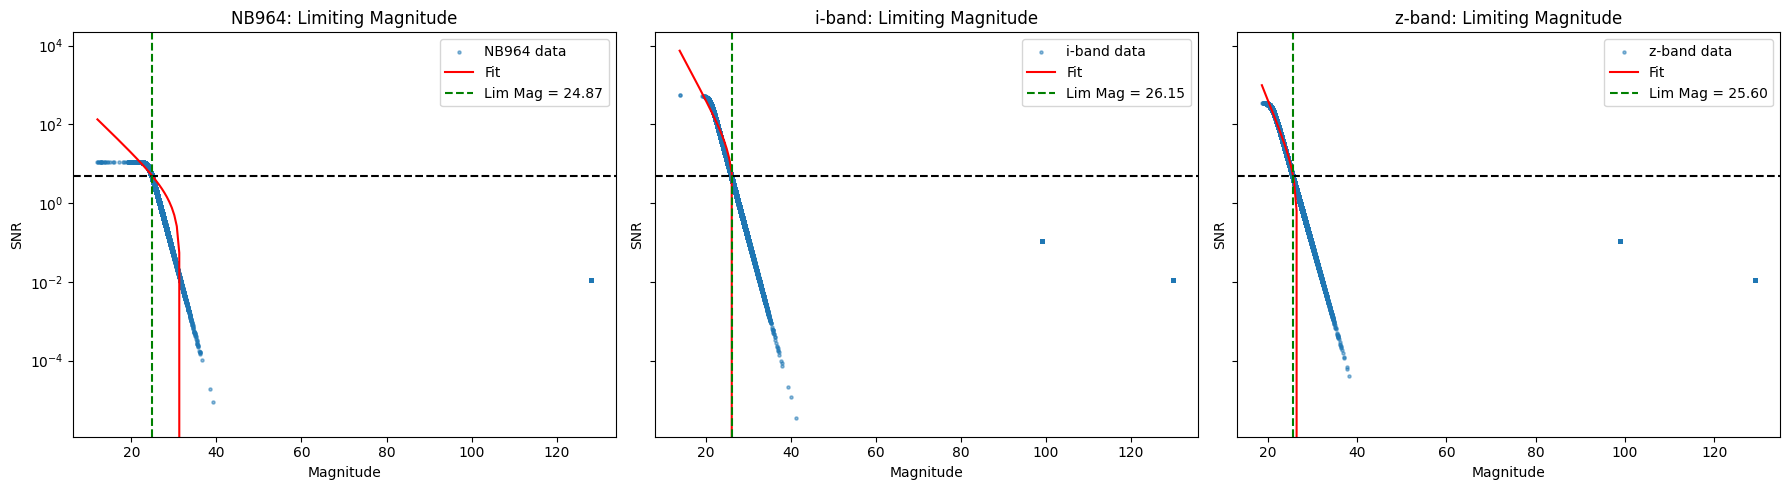

In [ ]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- File paths ----------
i_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_final_nbmasked.cat"
z_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_final_nbmasked.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_final_nbmasked.cat"

# ---------- Load Catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Define magnitude zero-points & errors ----------
ZP_i,  ZPERR_i  = 30.963, 0.002
ZP_z,  ZPERR_z  = 30.230, 0.003
ZP_nb, ZPERR_nb = 29.01078, 0.09539

# ---------- Convert to calibrated magnitudes ----------
i_df["MAG_APER_CAL"]  = i_df["MAG_APER"]  + ZP_i
z_df["MAG_APER_CAL"]  = z_df["MAG_APER"]  + ZP_z
nb_df["MAG_APER_CAL"] = nb_df["MAG_APER"] + ZP_nb

# ---------- Propagate zero-point errors ----------
i_df["MAGERR_APER_CAL"]  = np.sqrt(i_df["MAGERR_APER"]**2  + ZPERR_i**2)
z_df["MAGERR_APER_CAL"]  = np.sqrt(z_df["MAGERR_APER"]**2  + ZPERR_z**2)
nb_df["MAGERR_APER_CAL"] = np.sqrt(nb_df["MAGERR_APER"]**2 + ZPERR_nb**2)

# ---------- SNR function ----------
def magerr_to_snr(err):
    snr = (2.5 /( np.log(10) * err))
    snr[~np.isfinite(snr)] = 0
    return snr

# Compute SNR for i-band AUTO mags
i_df["SNR_AUTO"] = magerr_to_snr(i_df["MAG_APER_CAL"])

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

match_radius = 1  # arcsec
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Create aligned magnitude and error arrays ----------
nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER_CAL"].values

z_mag = np.full(nb_mag.shape, 99.0)
z_err = np.full(nb_mag.shape, 9.9)
z_mag[z_match] = z_df["MAG_APER_CAL"].values[idx_z[z_match]]
z_err[z_match] = z_df["MAGERR_APER_CAL"].values[idx_z[z_match]]

i_mag = np.full(nb_mag.shape, 99.0)
i_err = np.full(nb_mag.shape, 9.9)
i_mag[i_match] = i_df["MAG_APER_CAL"].values[idx_i[i_match]]
i_err[i_match] = i_df["MAGERR_APER_CAL"].values[idx_i[i_match]]

# ---------- Compute SNR for i-band ----------
i_snr_aper = np.zeros_like(nb_mag)
i_snr_aper[i_match] = magerr_to_snr(i_err[i_match])
i_snr_auto = np.zeros_like(nb_mag)
i_snr_auto[i_match] = magerr_to_snr(i_df["MAGERR_APER_CAL"].values[idx_i[i_match]])

# ---------- Colors & errors ----------
color_nb  = z_mag - nb_mag
color_err = np.sqrt(z_err**2 + nb_err**2)  # error in (z - NB)

# ---------- Apply cuts ----------
narrow_sel = (color_nb > 0.78)                  # NB excess
cont_sel   = (i_mag - z_mag > 1.0)              # Lyman break
faint_sel  = (i_snr_aper < 2.0) | (i_snr_auto < 2.0)  # faint in i-band
sig_sel    = np.abs(color_nb) > 2.5 * color_err # 2.5σ significance cut

# Final selection
final_sel = narrow_sel & cont_sel & faint_sel & sig_sel
lae_idx   = np.where(final_sel)[0]

# ---------- Save LAE candidates ----------
lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_APER", "MAGERR_APER"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")

print("Candidates passing each cut:")
print("NB excess cut     :", narrow_sel.sum())
print("Continuum break   :", cont_sel.sum())
print("Faint in i-band   :", faint_sel.sum())
print("Significance cut  :", sig_sel.sum())
print("Final LAEs        :", final_sel.sum())

lae_candidates.to_csv("/Users/aishwarya/Documents/Lyman_alpha/LAE_candidates.cat", index=False)
print("Saved LAE candidates to LAE_candidates.cat")

# ---------- Save debug diagnostics ----------
debug_df = pd.DataFrame({
    "RA": nb_df["RA"],
    "DEC": nb_df["DEC"],
    "NB_mag": nb_mag,
    "NB_err": nb_err,
    "Z_mag": z_mag,
    "Z_err": z_err,
    "I_mag": i_mag,
    "I_err": i_err,
    "Color_Z-NB": color_nb,
    "Color_err": color_err,
    "Pass_NB": narrow_sel,
    "Pass_Break": cont_sel,
    "Pass_Faint": faint_sel,
    "Pass_Significance": sig_sel,
    "Final_LAE": final_sel
})
debug_df.to_csv("LAE_debug_diagnostics.cat", index=False)
print("Saved diagnostics to LAE_debug_diagnostics.cat")

# ===============================================================
# === Limiting magnitude determination via SNR–magnitude fit ====
# ===============================================================

def snr_model(mag, a, b):
    """Exponential model: SNR(m) = a * exp(-b*m) + c"""
    return a * np.exp(-b * mag) 

def fit_limiting_mag(mag, err, bandname, snr_limit=5.0, ax=None):
    snr = magerr_to_snr(err)
    mask = (snr > 0) & (snr < 1e4) & np.isfinite(snr) & np.isfinite(mag)
    mag, snr = mag[mask], snr[mask]
    if len(mag) < 20:
        print(f"Not enough points to fit {bandname}.")
        return np.nan

    # Fit exponential
    p0 = [1e5, 1.0, 0.0]
    params, _ = curve_fit(snr_model, mag, snr, p0=p0, maxfev=10000)
    a, b, c = params

    # Solve for magnitude at SNR = snr_limit
    lim_mag = -(np.log((snr_limit - c)/a)) / b
    print(f"{snr_limit}σ limiting magnitude ({bandname}): {lim_mag:.2f}")

    # Plot if axis is provided
    if ax:
        ax.scatter(mag, snr, s=5, alpha=0.5, label=f"{bandname} data")
        xfit = np.linspace(mag.min(), mag.max(), 200)
        ax.plot(xfit, snr_model(xfit, *params), 'r-', label="Fit")
        ax.axhline(snr_limit, color='k', ls='--')
        ax.axvline(lim_mag, color='g', ls='--', label=f"Lim Mag = {lim_mag:.2f}")
        ax.set_yscale("log")
        ax.set_xlabel("Magnitude")
        ax.set_ylabel("SNR")
        ax.set_title(f"{bandname}: Limiting Magnitude")
        ax.legend()

    return lim_mag

# ---------- Compute & plot for each band ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

lim_nb = fit_limiting_mag(nb_mag, nb_err, "NB964", ax=axes[0])
lim_i  = fit_limiting_mag(i_mag,  i_err,  "i-band", ax=axes[1])
lim_z  = fit_limiting_mag(z_mag,  z_err,  "z-band", ax=axes[2])

plt.tight_layout()
plt.show()


Selected 5602 LAE candidates.
NB964 5σ limiting magnitude: 24.93


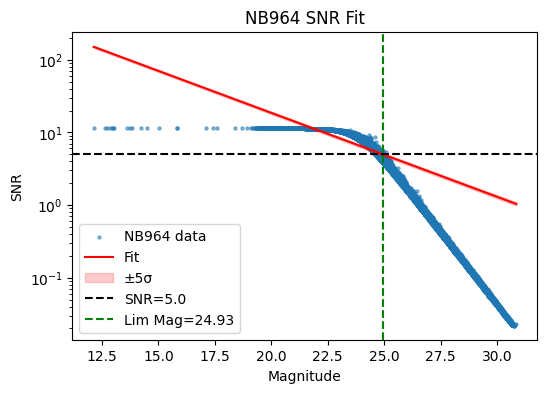

i-band 5σ limiting magnitude: 26.79


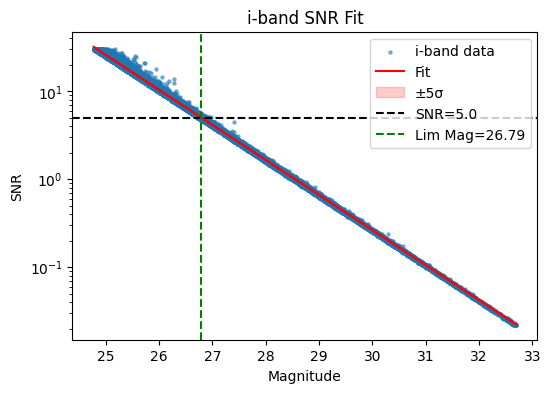

z-band 5σ limiting magnitude: 26.05


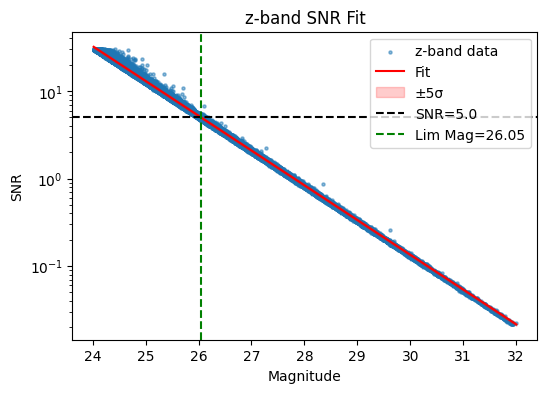

In [11]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- File paths ----------
i_file  = "/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_final_nbmasked.cat"
z_file  = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_final_nbmasked.cat"
nb_file = "/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_final_nbmasked.cat"

# ---------- Load catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df  = pd.read_csv(i_file,  sep=r"\s+", comment='#', names=colnames)
z_df  = pd.read_csv(z_file,  sep=r"\s+", comment='#', names=colnames)
nb_df = pd.read_csv(nb_file, sep=r"\s+", comment='#', names=colnames)

# ---------- Zero-points & error ----------
ZP_i, ZPERR_i   = 30.963, 0.002
ZP_z, ZPERR_z   = 30.230, 0.003
ZP_nb, ZPERR_nb = 29.01078, 0.09539

# ---------- Calibrated magnitudes ----------
for df, zp, zp_err in zip([i_df, z_df, nb_df],
                          [ZP_i, ZP_z, ZP_nb],
                          [ZPERR_i, ZPERR_z, ZPERR_nb]):
    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)

# ---------- SNR function ----------
def calculate_snr(err):
    snr = 2.5 / (np.log(10) * err)
    snr[~np.isfinite(snr)] = 0
    return snr

# ---------- Cross-match NB to Z and I ----------
nb_coords = SkyCoord(nb_df["RA"].values*u.deg, nb_df["DEC"].values*u.deg)
z_coords  = SkyCoord(z_df["RA"].values*u.deg, z_df["DEC"].values*u.deg)
i_coords  = SkyCoord(i_df["RA"].values*u.deg, i_df["DEC"].values*u.deg)

match_radius = 1.0  # arcsec
idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

# ---------- Aligned magnitude & error arrays ----------
def align_mag_err(nb_size, df, idx_match, match_flag):
    mag  = np.full(nb_size, 99.0)
    err  = np.full(nb_size, 9.9)
    mag[match_flag] = df["MAG_APER_CAL"].values[idx_match[match_flag]]
    err[match_flag] = df["MAGERR_APER_CAL"].values[idx_match[match_flag]]
    return mag, err

nb_mag = nb_df["MAG_APER_CAL"].values
nb_err = nb_df["MAGERR_APER_CAL"].values
z_mag, z_err = align_mag_err(len(nb_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(nb_mag), i_df, idx_i, i_match)

# ---------- SNR for i-band ----------
i_snr_aper = np.zeros_like(nb_mag)
i_snr_aper[i_match] = calculate_snr(i_err[i_match])
i_snr_auto = np.zeros_like(nb_mag)
i_snr_auto[i_match] = calculate_snr(i_df["MAGERR_APER_CAL"].values[idx_i[i_match]])

# ---------- Colors & errors ----------
color_nb  = z_mag - nb_mag
color_err = np.sqrt(z_err**2 + nb_err**2)

# ---------- Apply selection cuts ----------
narrow_sel = color_nb > 0.78
cont_sel   = (i_mag - z_mag) > 1.0
faint_sel  = (i_snr_aper < 2.0) | (i_snr_auto < 2.0)
sig_sel    = np.abs(color_nb) > 2.5 * color_err

final_sel = narrow_sel & cont_sel & faint_sel & sig_sel
lae_idx   = np.where(final_sel)[0]

# ---------- LAE candidates ----------
lae_candidates = nb_df.iloc[lae_idx][["RA", "DEC", "MAG_APER", "MAGERR_APER"]]
print(f"Selected {len(lae_candidates)} LAE candidates.")

# ---------- Debug diagnostics ----------
debug_df = pd.DataFrame({
    "RA": nb_df["RA"], "DEC": nb_df["DEC"],
    "NB_mag": nb_mag, "NB_err": nb_err,
    "Z_mag": z_mag, "Z_err": z_err,
    "I_mag": i_mag, "I_err": i_err,
    "Color_Z-NB": color_nb, "Color_err": color_err,
    "Pass_NB": narrow_sel, "Pass_Break": cont_sel,
    "Pass_Faint": faint_sel, "Pass_Significance": sig_sel,
    "Final_LAE": final_sel
})

# ---------- Exponential SNR fit ----------
def exponential_func(mag, a, b):
    return a * np.exp(b * mag)

def fit_snr_exponential(mag, err, snr_limit=5.0, bandname="Band"):
    # Filter bad points
    mask = (mag < 99) & (err < 50)
    mag, err = mag[mask], err[mask]
    snr = calculate_snr(err)
    
    # Sort by magnitude
    sort_idx = np.argsort(mag)
    mag, snr = mag[sort_idx], snr[sort_idx]
    cut = (snr < 30) & (snr > 0)
    mag, snr = mag[cut], snr[cut]

    
    # Fit exponential
    params, cov = curve_fit(exponential_func, mag, snr, maxfev=5000)
    a_fit, b_fit = params
    a_err, b_err = np.sqrt(np.diag(cov))
    
    # Generate fine x for plotting
    x_finer = np.linspace(mag.min(), mag.max(), 1000)
    y_fit = exponential_func(x_finer, a_fit, b_fit)
    y_upper = exponential_func(x_finer, a_fit + 5*a_err, b_fit + 5*b_err)
    y_lower = exponential_func(x_finer, a_fit - 5*a_err, b_fit - 5*b_err)
    
    # Limiting magnitude at given SNR
    lim_mag = np.log(snr_limit / a_fit) / b_fit
    print(f"{bandname} 5σ limiting magnitude: {lim_mag:.2f}")
    
    # Plot
    plt.figure(figsize=(6,4))
    plt.scatter(mag, snr, s=5, alpha=0.5, label=f"{bandname} data")
    plt.plot(x_finer, y_fit, 'r-', label='Fit')
    plt.fill_between(x_finer, y_lower, y_upper, color='r', alpha=0.2, label='±5σ')
    plt.axhline(snr_limit, color='k', ls='--', label=f"SNR={snr_limit}")
    plt.axvline(lim_mag, color='g', ls='--', label=f"Lim Mag={lim_mag:.2f}")
    plt.xlabel("Magnitude")
    plt.ylabel("SNR")
    plt.yscale("log")
    plt.title(f"{bandname} SNR Fit")
    plt.legend()
    plt.show()
    
    return lim_mag

# ---------- Run SNR fit for all bands ----------
lim_nb = fit_snr_exponential(nb_mag, nb_err, bandname="NB964")
lim_i  = fit_snr_exponential(i_mag, i_err, bandname="i-band")
lim_z  = fit_snr_exponential(z_mag, z_err, bandname="z-band")


In [ ]:
"""
Fit exponential curves to SNR-type data to determine depths.
Uses only standard packages and specified zero points.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Zero points ----------
ZP_i, ZPERR_i = 30.963, 0.002
ZP_z, ZPERR_z = 30.230, 0.003
ZP_nb, ZPERR_nb = 29.01078, 0.09539

# ---------- Functions ----------
def exponential_func(mag, a, b):
    """Exponential function for fitting: SNR = a * exp(b * mag)."""
    return a * np.exp(b * mag)

def magerr_to_snr(err):
    """Convert magnitude error to SNR."""
    return (2.5 / np.log(10)) / err

def load_catalog(file_path, zp, mag_column="MAG_APER", err_column="MAGERR_APER"):
    """Load catalog, apply cuts, return mag (corrected), err, snr."""
    # read whitespace-delimited ASCII
    data = np.genfromtxt(file_path, names=True, dtype=None, encoding=None, comments="#")

    # handle structured array correctly
    mag = data[mag_column]
    err = data[err_column]

    # mask invalid values
    mask = (mag != 99) & (err > 0) & (err < 50) & np.isfinite(mag) & np.isfinite(err)
    mag, err = mag[mask], err[mask]

    if len(mag) == 0:
        raise ValueError(f"No valid data found in {file_path}")

    # sort by magnitude
    order = np.argsort(mag)
    mag, err = mag[order], err[order]

    # compute SNR
    snr = magerr_to_snr(err)

    # remove very high SNR outliers
    mask_snr = snr < 1e4
    mag, err, snr = mag[mask_snr], err[mask_snr], snr[mask_snr]

    # apply zero point correction
    mag += zp
    return mag, err, snr

def fit_and_plot(mag, snr, bandname, outfile=None):
    """Fit exponential curve, plot SNR, return parameters and limiting mags."""
    # initial guess for curve_fit
    p0 = [1e5, -0.5]
    params, cov = curve_fit(exponential_func, mag, snr, p0=p0, maxfev=10000)
    a_fit, b_fit = params
    a_err, b_err = np.sqrt(np.diag(cov))

    # magnitude at given SNR
    def mag_at_snr(snr_val):
        return np.log(snr_val / a_fit) / b_fit

    # smooth curve
    xfit = np.linspace(mag.min(), mag.max(), 1000)
    yfit = exponential_func(xfit, a_fit, b_fit)

    # plot
    plt.figure(figsize=(6,4))
    plt.scatter(mag, snr, s=3, alpha=0.5, label=f"{bandname} data")
    plt.plot(xfit, yfit, 'r-', lw=1, label="Exponential fit")
    plt.yscale("log")
    plt.xlabel("Magnitude")
    plt.ylabel("SNR")
    plt.title(f"SNR vs Magnitude: {bandname}")
    plt.legend()
    plt.grid(True)
    
    plt.show()

    # print limiting magnitudes
    print(f"\n{bandname} limiting magnitudes for SNR=1..5:")
    for s in range(1,6):
        try:
            print(f"  SNR={s}: {mag_at_snr(s):.2f}")
        except Exception:
            print(f"  SNR={s}: could not compute (fit issue)")

    return params

# ---------- Run for all catalogs ----------
if __name__ == "__main__":
    catalogs = [
        ("/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band.cat",        ZP_z, "z-band"),
        ("/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_depth.cat",  ZP_z, "z-band depth"),
        ("/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band.cat",     ZP_nb, "NB964"),
        ("/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band.cat",        ZP_i, "i-band"),
        ("/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_depth.cat",  ZP_i, "i-band depth"),
    ]

    for file_path, zp, label in catalogs:
        try:
            mag, err, snr = load_catalog(file_path, zp)
            fit_and_plot(mag, snr, label)
        except Exception as e:
            print(f"Error processing {label}: {e}")
